# making more wont stop (Edition 3)

In [23]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [24]:
words = open('names.txt', 'r').read().splitlines()
words[:8] 

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [25]:
len(words)

32033

In [26]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [59]:
block_size = 3

def build_database(words):
    X, Y = [], []

    for w in words:
        context = [0] *block_size

        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_database(words[:n1])
Xdev, Ydev = build_database(words[n1:n2])
Xte, Yte = build_database(words[n2:])

torch.Size([182580, 3]) torch.Size([182580])
torch.Size([22767, 3]) torch.Size([22767])
torch.Size([22799, 3]) torch.Size([22799])


In [60]:
n_embd = 10
n_hidden = 200

g = torch.Generator()
C = torch.randn((vocab_size, n_embd),             generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3) / (n_embd * block_size)**0.5
b1 = torch.randn(n_hidden,                        generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.01
b2 = torch.randn((vocab_size),                    generator=g) * 0

bngain = torch.randn((1, n_hidden))
bnbias = torch.randn((1, n_hidden))
bnmean_running = torch.zeros((1, n_hidden))
bnstd_running = torch.ones((1, n_hidden))

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad=True

12297


tensor(0.0110) tensor(1.0089)
tensor(-0.0008) tensor(1.0081)


(array([2.25331008e-05, 6.75993025e-05, 6.75993025e-05, 1.35198605e-04,
        2.47864109e-04, 3.83062714e-04, 9.23857135e-04, 1.26185365e-03,
        2.05051218e-03, 3.78556094e-03, 5.65580831e-03, 1.01624285e-02,
        1.54126410e-02, 2.49892088e-02, 3.83288045e-02, 5.59271563e-02,
        8.39132675e-02, 1.18839574e-01, 1.61562333e-01, 2.15574176e-01,
        2.75286893e-01, 3.32160440e-01, 3.77406906e-01, 4.13550000e-01,
        4.26281202e-01, 3.99061216e-01, 3.59222694e-01, 3.06022043e-01,
        2.46061461e-01, 1.91328559e-01, 1.43896382e-01, 1.00475097e-01,
        6.75542363e-02, 4.58097940e-02, 3.08027489e-02, 1.93559336e-02,
        1.27537351e-02, 7.86405219e-03, 4.39395466e-03, 3.37996513e-03,
        1.78011497e-03, 1.03652264e-03, 8.56257832e-04, 4.28128916e-04,
        2.25331008e-04, 1.35198605e-04, 4.50662017e-05, 9.01324034e-05,
        0.00000000e+00, 4.50662017e-05]),
 array([-5.38526964, -5.16337386, -4.94147808, -4.7195823 , -4.49768652,
        -4.27579074, 

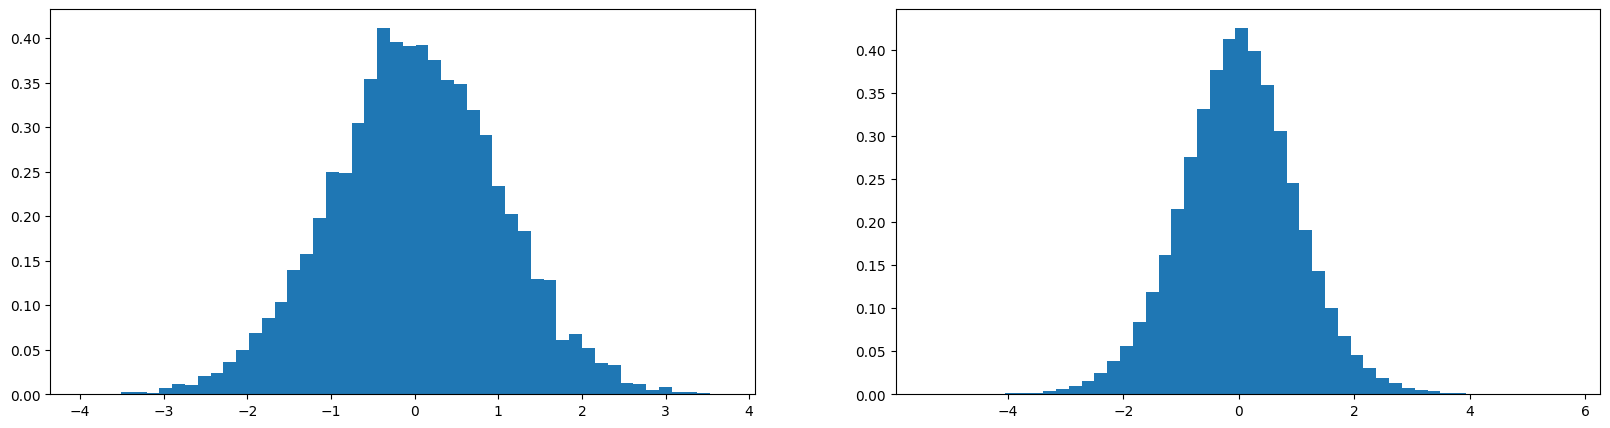

In [61]:
x = torch.randn(1000, 10)
w = torch.randn(10, 200) / 10**0.5
y = x @ w
print(x.mean(), x.std())
print(y.mean(), y.std())

plt.figure(figsize=(20, 5))
plt.subplot(121)
plt.hist(x.view(-1).tolist(), 50, density=True)
plt.subplot(122)
plt.hist(y.view(-1).tolist(), 50, density=True)

In [62]:
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]

    emb = C[Xb]
    embcat = emb.view(emb.shape[0], -1)
    
    hpreact = embcat @ W1 + b1
    bnmeani = hpreact.mean(0, keepdim=True)
    bnstdi = hpreact.std(0, keepdim=True)
    hpreact = bngain * (hpreact - bnmeani) / bnstdi + bnbias

    with torch.no_grad():
        bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
        bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi

    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Yb)

    for p in parameters:
        p.grad = None
    loss.backward()

    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data -= lr * p.grad
    
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item(): .4f}')
    lossi.append(loss.log10().item())
    break

      0/ 200000:  3.3216


(array([539., 243., 170., 167., 146., 150., 149., 128., 119., 111., 128.,
        140.,  98.,  96.,  68.,  75.,  57.,  78.,  72.,  85.,  88.,  82.,
         72.,  81.,  79.,  84.,  80.,  68.,  70.,  68.,  84.,  94., 106.,
         72.,  83.,  94., 122., 118., 110., 124., 122., 107., 127., 128.,
        128., 148., 172., 186., 203., 481.]),
 array([-9.99996305e-01, -9.59996481e-01, -9.19996657e-01, -8.79996834e-01,
        -8.39997010e-01, -7.99997187e-01, -7.59997363e-01, -7.19997540e-01,
        -6.79997716e-01, -6.39997892e-01, -5.99998069e-01, -5.59998245e-01,
        -5.19998422e-01, -4.79998598e-01, -4.39998775e-01, -3.99998951e-01,
        -3.59999127e-01, -3.19999304e-01, -2.79999480e-01, -2.39999657e-01,
        -1.99999833e-01, -1.60000010e-01, -1.20000186e-01, -8.00003624e-02,
        -4.00005388e-02, -7.15255737e-07,  3.99991083e-02,  7.99989319e-02,
         1.19998755e-01,  1.59998579e-01,  1.99998403e-01,  2.39998226e-01,
         2.79998050e-01,  3.19997873e-01,  3.59997

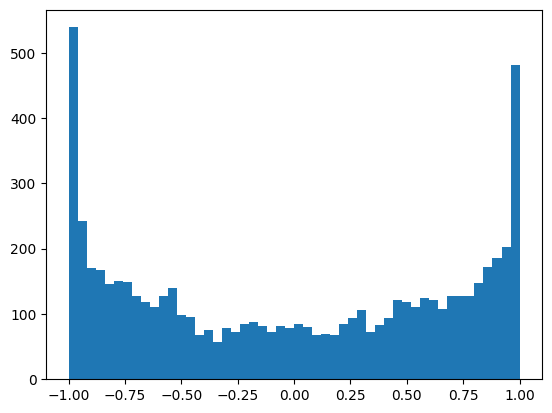

In [63]:
plt.hist(h.view(-1).tolist(), 50)

(array([  1.,   2.,   1.,   2.,   3.,   2.,   7.,   5.,   7.,  19.,  16.,
         26.,  39.,  50.,  56.,  99.,  95., 130., 182., 204., 290., 407.,
        475., 451., 490., 490., 509., 555., 419., 327., 271., 186., 140.,
        105., 122.,  83.,  42.,  28.,  18.,  11.,  13.,  10.,   1.,   4.,
          4.,   1.,   0.,   1.,   0.,   1.]),
 array([-6.6011157 , -6.34031892, -6.07952213, -5.81872535, -5.55792856,
        -5.29713178, -5.03633499, -4.77553821, -4.51474142, -4.25394464,
        -3.99314785, -3.73235106, -3.47155428, -3.21075749, -2.94996071,
        -2.68916392, -2.42836714, -2.16757035, -1.90677357, -1.64597678,
        -1.38518   , -1.12438321, -0.86358643, -0.60278964, -0.34199286,
        -0.08119607,  0.17960072,  0.4403975 ,  0.70119429,  0.96199107,
         1.22278786,  1.48358464,  1.74438143,  2.00517821,  2.265975  ,
         2.52677178,  2.78756857,  3.04836535,  3.30916214,  3.56995893,
         3.83075571,  4.0915525 ,  4.35234928,  4.61314607,  4.87394285,
 

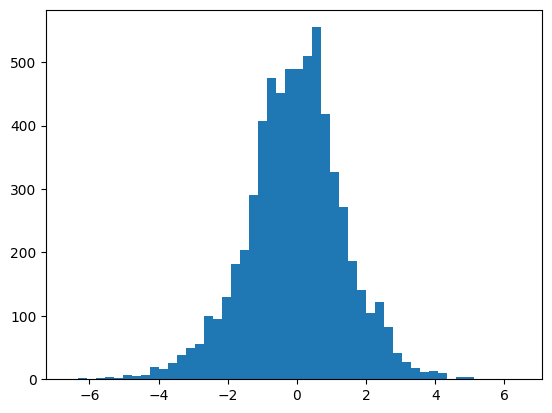

In [64]:
plt.hist(hpreact.view(-1).tolist(), 50)

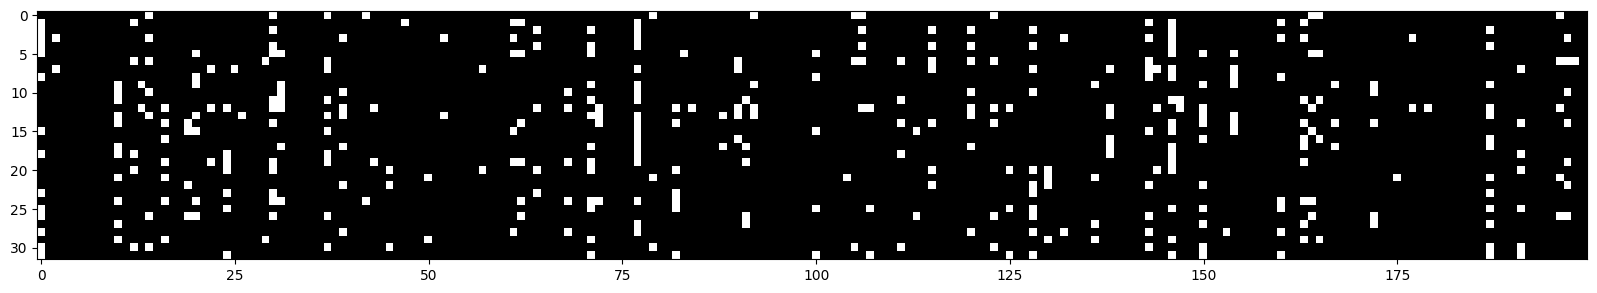

In [65]:
plt.figure(figsize=(20,10))
plt.imshow(h.abs() > 0.99, cmap='gray', interpolation='nearest')

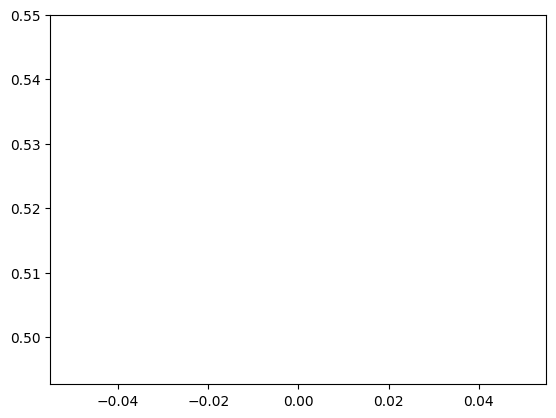

In [66]:
plt.plot(lossi)

In [67]:
with torch.no_grad():
  emb = C[Xtr]
  embcat = emb.view(emb.shape[0], -1)
  hpreact = embcat @ W1 # + b1
  
  bnmean = hpreact.mean(0, keepdim=True)
  bnstd = hpreact.std(0, keepdim=True)

In [68]:
@torch.no_grad()
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Yval),
        'test': (Xte, Yte),
    }[split]

    emb = C[x]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 + b1
    hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')
split_loss('test')

train 3.0668065547943115


ValueError: Expected input batch_size (22767) to match target batch_size (22655).

In [69]:
g = torch.Generator()

for _ in range(20):

    out = []
    context = [0] * block_size

    while True:
        emb = C[torch.tensor([context])]
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)

        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)

        if ix == 0:
            break
    
    print(''.join(itos[i] for i in out))

triolniwhstvgxyagp.
wxfj.
fqjy.
hedueznibeoptjevowquxrvkrpyadwblwpzetfbqzezczozyhu.
zgcffnzvdkxrbtouwqkvcbtbnwlqvpyzxujmmbtfj.
aki.
fvvt.
hqur.
geovaneafhuqynfyasxopgmyeuziyluozyewncbxydr.
fzb.
cseonzfx.
zlooqtovjuplouijcmtkretxtkbzhondolznubicpawldyyrmaxhjlzdzdxioydvwvlohhmijivocpi.
wfmhlkjiqgpgwiptsi.
.
hkjwsaisgxobzqwedunqqgansvapwyzfsknukkdzp.
nedwnalmxyyviolgf.
znsxhdvfwpbqwrsyykzzolzavtiw.
treu.
.
cgbmwqfyxdfcjz.


# now we do sm real shii

In [70]:
class Linear:
  
  def __init__(self, fan_in, fan_out, bias=True):
    self.weight = torch.randn((fan_in, fan_out), generator=g) / fan_in**0.5
    self.bias = torch.zeros(fan_out) if bias else None
  
  def __call__(self, x):
    self.out = x @ self.weight
    if self.bias is not None:
      self.out += self.bias
    return self.out
  
  def parameters(self):
    return [self.weight] + ([] if self.bias is None else [self.bias])


class BatchNorm1d:
  
  def __init__(self, dim, eps=1e-5, momentum=0.1):
    self.eps = eps
    self.momentum = momentum
    self.training = True
    
    self.gamma = torch.ones(dim)
    self.beta = torch.zeros(dim)
    
    self.running_mean = torch.zeros(dim)
    self.running_var = torch.ones(dim)
  
  def __call__(self, x):
   
    if self.training:
      xmean = x.mean(0, keepdim=True)
      xvar = x.var(0, keepdim=True)
    else:
      xmean = self.running_mean
      xvar = self.running_var
    xhat = (x - xmean) / torch.sqrt(xvar + self.eps)
    self.out = self.gamma * xhat + self.beta
    
    if self.training:
      with torch.no_grad():
        self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
        self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
    return self.out
  
  def parameters(self):
    return [self.gamma, self.beta]

class Tanh:
  def __call__(self, x):
    self.out = torch.tanh(x)
    return self.out
  def parameters(self):
    return []

n_embd = 10
n_hidden = 100
g = torch.Generator().manual_seed(2147483647)

C = torch.randn((vocab_size, n_embd),            generator=g)
layers = [
  Linear(n_embd * block_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(           n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(           n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(           n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(           n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(           n_hidden, vocab_size, bias=False), BatchNorm1d(vocab_size),
]
# layers = [
#   Linear(n_embd * block_size, n_hidden), Tanh(),
#   Linear(           n_hidden, n_hidden), Tanh(),
#   Linear(           n_hidden, n_hidden), Tanh(),
#   Linear(           n_hidden, n_hidden), Tanh(),
#   Linear(           n_hidden, n_hidden), Tanh(),
#   Linear(           n_hidden, vocab_size),
# ]

with torch.no_grad():
  
  layers[-1].gamma *= 0.1
  #layers[-1].weight *= 0.1
  for layer in layers[:-1]:
    if isinstance(layer, Linear):
      layer.weight *= 1.0 #5/3

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters))
for p in parameters:
  p.requires_grad = True

47024


In [79]:
max_steps = 200000
batch_size = 32
lossi = []
ud = []

for i in range(max_steps):
  
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix]
  
  # forward pass
  emb = C[Xb]
  x = emb.view(emb.shape[0], -1)
  for layer in layers:
    x = layer(x)
  loss = F.cross_entropy(x, Yb)
  
  # backward pass
  for layer in layers:
    layer.out.retain_grad()
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  lr = 0.1 if i < 150000 else 0.01
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0:
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())
  with torch.no_grad():
    ud.append([((lr*p.grad).std() / p.data.std()).log10().item() for p in parameters])

  # if i >= 1000:
  #   break

      0/ 200000: 2.3271
  10000/ 200000: 1.9494
  20000/ 200000: 2.1818
  30000/ 200000: 1.8150
  40000/ 200000: 2.2431
  50000/ 200000: 2.1988
  60000/ 200000: 2.1518
  70000/ 200000: 2.0880
  80000/ 200000: 1.7003
  90000/ 200000: 1.8124
 100000/ 200000: 1.9898
 110000/ 200000: 2.0939
 120000/ 200000: 1.8675
 130000/ 200000: 2.6386
 140000/ 200000: 1.8182
 150000/ 200000: 2.0891
 160000/ 200000: 1.4752
 170000/ 200000: 1.8320
 180000/ 200000: 1.6573
 190000/ 200000: 1.9626


layer 2 (      Tanh): mean -0.04, std 0.85, saturated: 43.19%
layer 5 (      Tanh): mean +0.03, std 0.91, saturated: 60.78%
layer 8 (      Tanh): mean -0.00, std 0.92, saturated: 62.09%
layer 11 (      Tanh): mean +0.02, std 0.92, saturated: 63.22%
layer 14 (      Tanh): mean -0.03, std 0.92, saturated: 63.44%


Text(0.5, 1.0, 'activation distribution')

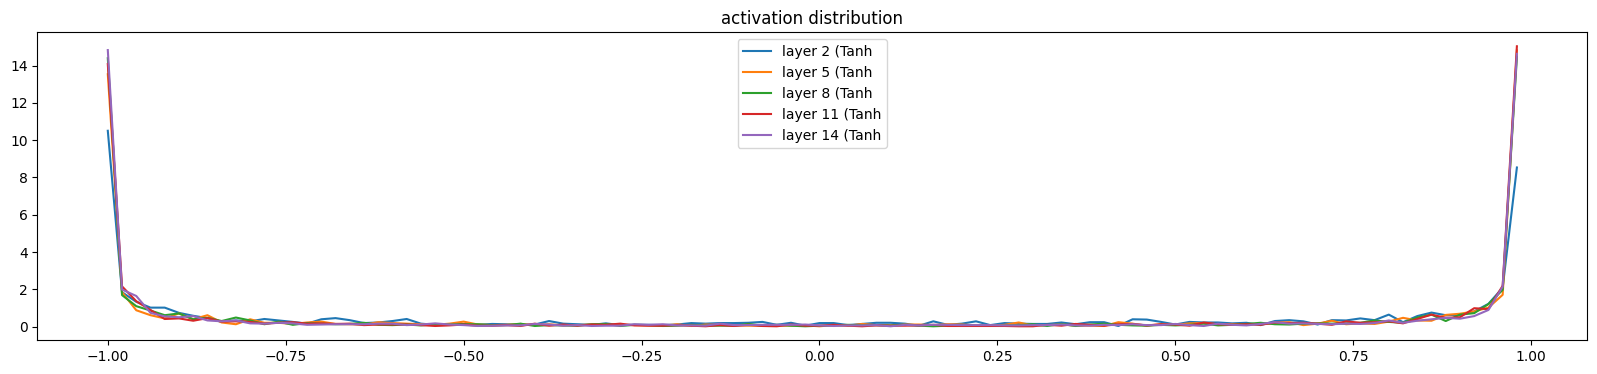

In [80]:
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out
    print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('activation distribution')

layer 2 (      Tanh): mean +0.000032, std 3.047221e-03
layer 5 (      Tanh): mean +0.000078, std 2.963578e-03
layer 8 (      Tanh): mean -0.000055, std 2.836606e-03
layer 11 (      Tanh): mean +0.000024, std 3.153212e-03
layer 14 (      Tanh): mean -0.000073, std 4.055999e-03


Text(0.5, 1.0, 'gradient distribution')

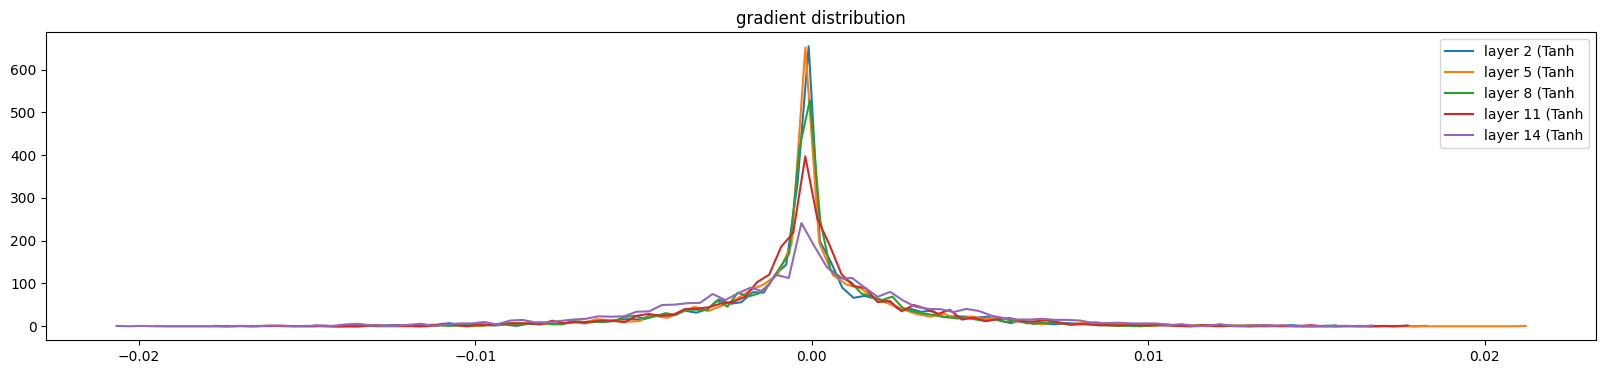

In [81]:
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out.grad
    print('layer %d (%10s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean(), t.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('gradient distribution')

weight   (27, 10) | mean -0.000077 | std 1.289243e-02 | grad:data ratio 1.118910e-02
weight  (30, 100) | mean +0.000044 | std 7.691181e-03 | grad:data ratio 1.729001e-02
weight (100, 100) | mean +0.000043 | std 4.996187e-03 | grad:data ratio 1.866118e-02
weight (100, 100) | mean +0.000008 | std 5.484019e-03 | grad:data ratio 2.132152e-02
weight (100, 100) | mean +0.000014 | std 5.459572e-03 | grad:data ratio 2.200625e-02
weight (100, 100) | mean +0.000040 | std 5.945331e-03 | grad:data ratio 2.436168e-02
weight  (100, 27) | mean +0.000021 | std 1.449318e-02 | grad:data ratio 4.284130e-02


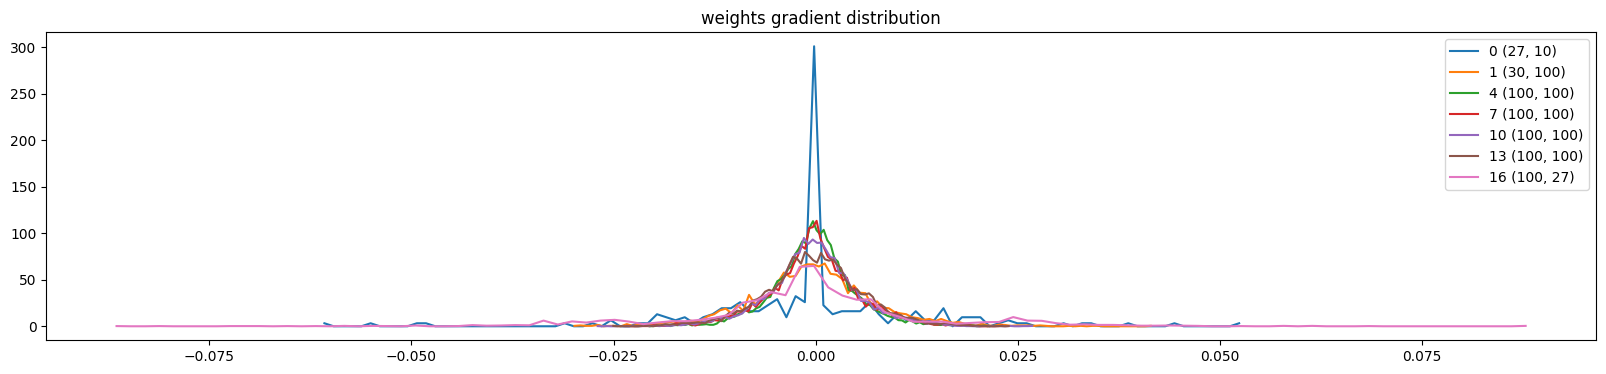

In [82]:
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i,p in enumerate(parameters):
  t = p.grad
  if p.ndim == 2:
    print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std() / p.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('weights gradient distribution');

weight   (27, 10) | mean -0.000077 | std 1.289243e-02 | grad:data ratio 1.118910e-02
weight  (30, 100) | mean +0.000044 | std 7.691181e-03 | grad:data ratio 1.729001e-02
weight (100, 100) | mean +0.000043 | std 4.996187e-03 | grad:data ratio 1.866118e-02
weight (100, 100) | mean +0.000008 | std 5.484019e-03 | grad:data ratio 2.132152e-02
weight (100, 100) | mean +0.000014 | std 5.459572e-03 | grad:data ratio 2.200625e-02
weight (100, 100) | mean +0.000040 | std 5.945331e-03 | grad:data ratio 2.436168e-02
weight  (100, 27) | mean +0.000021 | std 1.449318e-02 | grad:data ratio 4.284130e-02


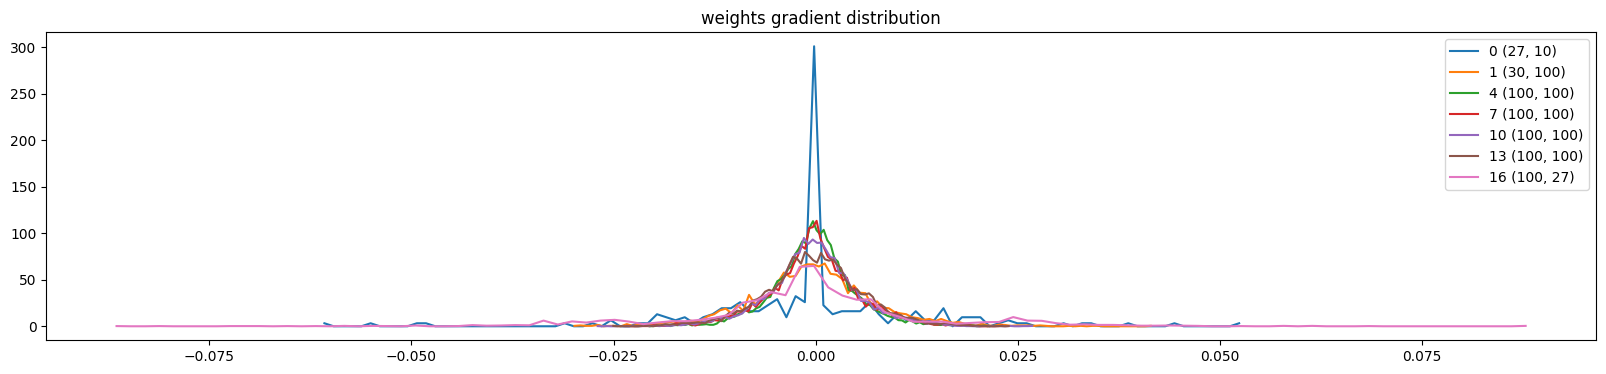

In [83]:
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i,p in enumerate(parameters):
  t = p.grad
  if p.ndim == 2:
    print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std() / p.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('weights gradient distribution');

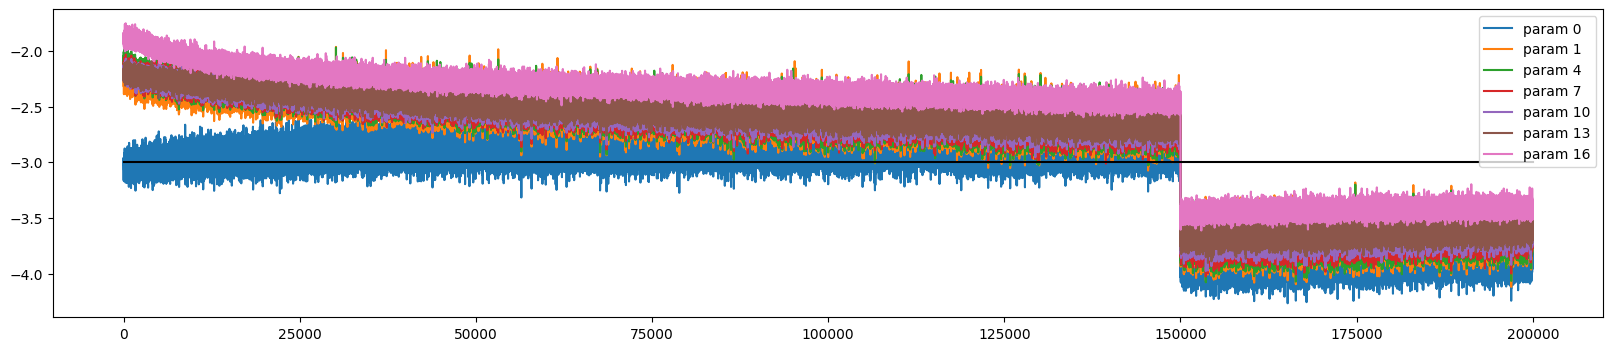

In [84]:
plt.figure(figsize=(20, 4))
legends = []
for i,p in enumerate(parameters):
  if p.ndim == 2:
    plt.plot([ud[j][i] for j in range(len(ud))])
    legends.append('param %d' % i)
plt.plot([0, len(ud)], [-3, -3], 'k') # these ratios should be ~1e-3, indicate on plot
plt.legend(legends);

In [85]:
@torch.no_grad()
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x]
  x = emb.view(emb.shape[0], -1)
  for layer in layers:
    x = layer(x)
  loss = F.cross_entropy(x, y)
  print(split, loss.item())

for layer in layers:
  layer.training = False
split_loss('train')
split_loss('val')
split_loss('test')

train 1.9591033458709717
val 2.0839715003967285
test 2.080880880355835


In [86]:
g = torch.Generator()

for _ in range(20):
    
    out = []
    context = [0] * block_size
    while True:
      emb = C[torch.tensor([context])]
      x = emb.view(emb.shape[0], -1)
      for layer in layers:
        x = layer(x)
      logits = x
      probs = F.softmax(logits, dim=1)

      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      
      context = context[1:] + [ix]
      out.append(ix)
      
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out))

kodilyn.
henora.
alvinia.
jalay.
hel.
ezrielopanellaguadvi.
deanna.
maiero.
azely.
gablu.
zicfonzo.
kriston.
alvien.
nylah.
azaidamalay.
aki.
fartemila.
deonaneashaakiyah.
annamya.
ziyla.
